# **ACF (Autocorrelation Function) e PACF (Partial Autocorrelation Function)**


Os gráficos **ACF (Autocorrelation Function**) e **PACF (Partial Autocorrelation Function)** são as duas principais ferramentas de diagnóstico visual em séries temporais.Eles são essenciais para identificar o comportamento da série (tendência, sazonalidade e memória), verificar a estacionariedade e determinar os parâmetros de ordem $(p, d, q)$ na modelação de modelos **ARIMA **e **SARIMA.**

## **1. ACF (Função de Autocorrelação)**

A ACF mede a correlação entre a série temporal $Y_t$ e a sua versão atrasada $Y_{t-k}$ (no desfasamento ou lag $k$).O efeito "Cascata": A ACF inclui a influência indireta dos lags intermédios. Por exemplo, a autocorrelação no desfasamento $k=3$ mede a relação de $Y_t$ com $Y_{t-3}$, mas essa relação carrega o efeito indireto de $Y_t$ passar por $Y_{t-1}$ e $Y_{t-2}$.

### **1.1 Padrões Típicos na ACF:**

* **Série Não Estacionária (com Tendência):** As barras da ACF começam muito altas e decrescem muito lentamente ao longo dos lags.
* **Sazonalidade:** Apresenta "picos" recorrentes e significativos em intervalos fixos (ex: picos nos lags 12, 24, 36 indicam sazonalidade mensal/anual).
* **Processo de Média Móvel — $MA(q)$**: A ACF corta abruptamente (vai para zero) após o lag $q$.


##  **2. PACF (Função de Autocorrelação Parcial)**

A PACF mede a correlação direta entre $Y_t$ e $Y_{t-k}$, removendo a influência de todos os desfasamentos intermédios ($Y_{t-1}, Y_{t-2}, \dots, Y_{t-k+1}$).

* **Isolamento do efeito:** Responde à pergunta: "Existem evidências de que o valor de há 3 dias atrás ($Y_{t-3}$) afeta diretamente o valor de hoje ($Y_t$), ignorando o que aconteceu nos dias 1 e 2?".

### **2.1 Padrões Típicos na PACF:**
 * **Processo Autoregressivo $AR(p)$:** A PACF corta abruptamente (vai para zero) após o lag $p$.
 * **Série com Tendência:** Geralmente apresenta um primeiro lag próximo de $1.0$ e os restantes caem vertiginosamente para a zona de insignificância.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from  matplotlib.pylab import rcParams
rcParams['figure.figsize'] =15,7

## **Exemplo 1 - Série anual**

Vamos criar uma série temporal com valores **normalmente distribuidos** com **média zero** e **variância 1**. A série se inicia no ano de **1985** e termina no ano de **2025**.

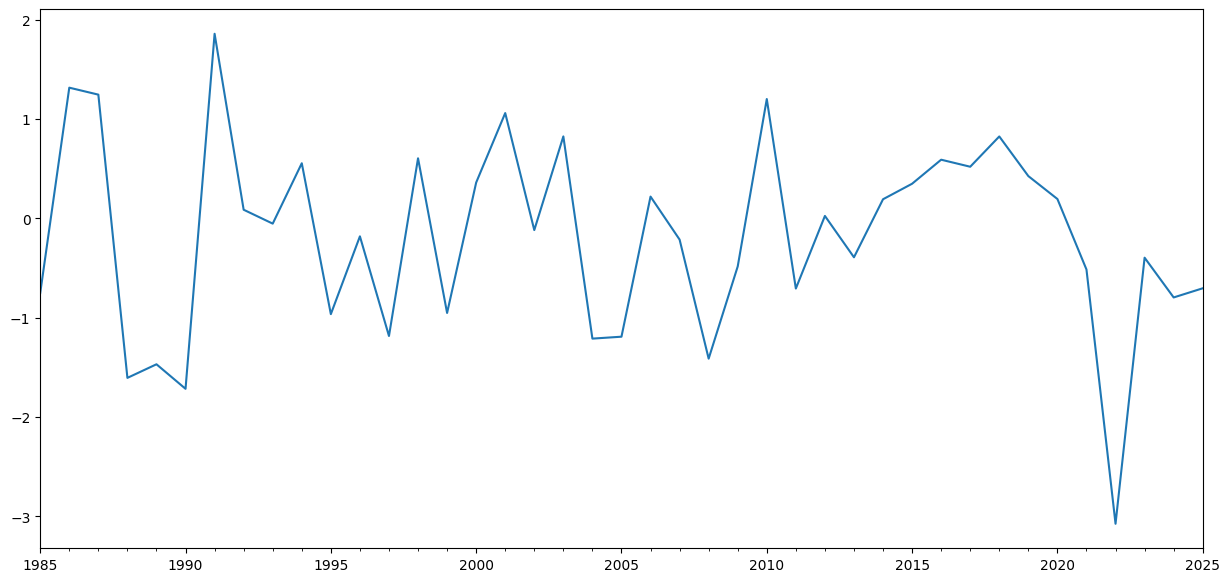

In [2]:
np.random.seed(44)
dados_v0 =np.random.normal(0,1,41)
dados_v1 = pd.DataFrame(dados_v0,columns=['valores'])
indice = pd.date_range('1985', periods=len(dados_v0),freq='YE')
serie_v1= pd.Series(dados_v1['valores'].values, index=indice)
serie_v1.plot()
plt.show()

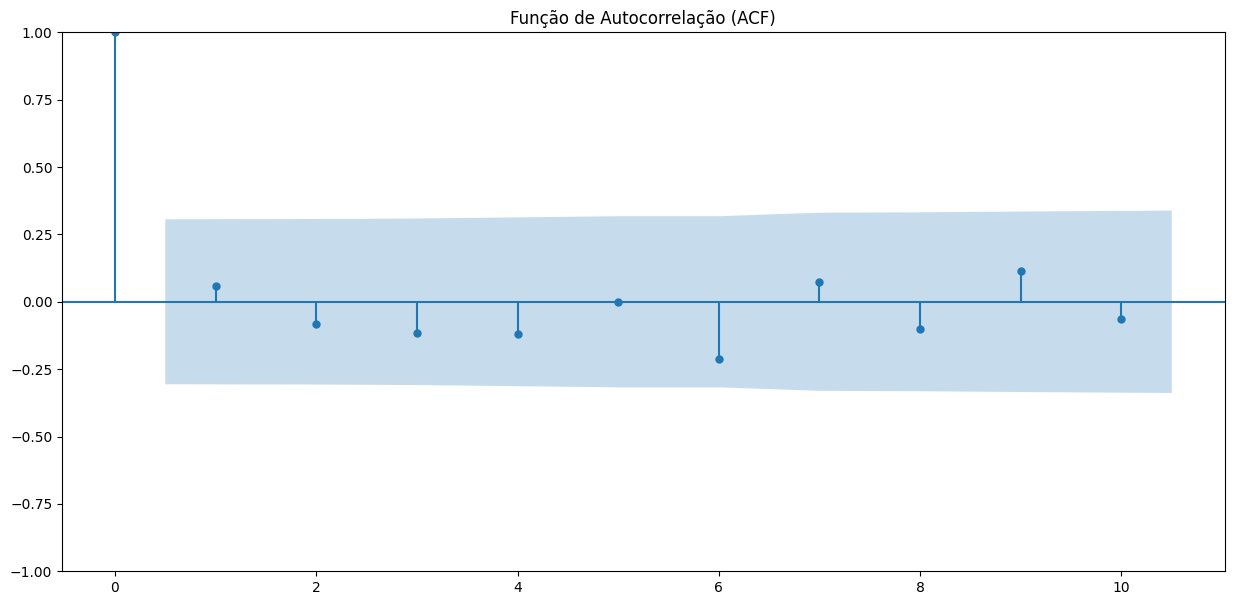

In [3]:
plot_acf(serie_v1, lags=10, color='#1f77b4', title='Função de Autocorrelação (ACF)')
plt.show()

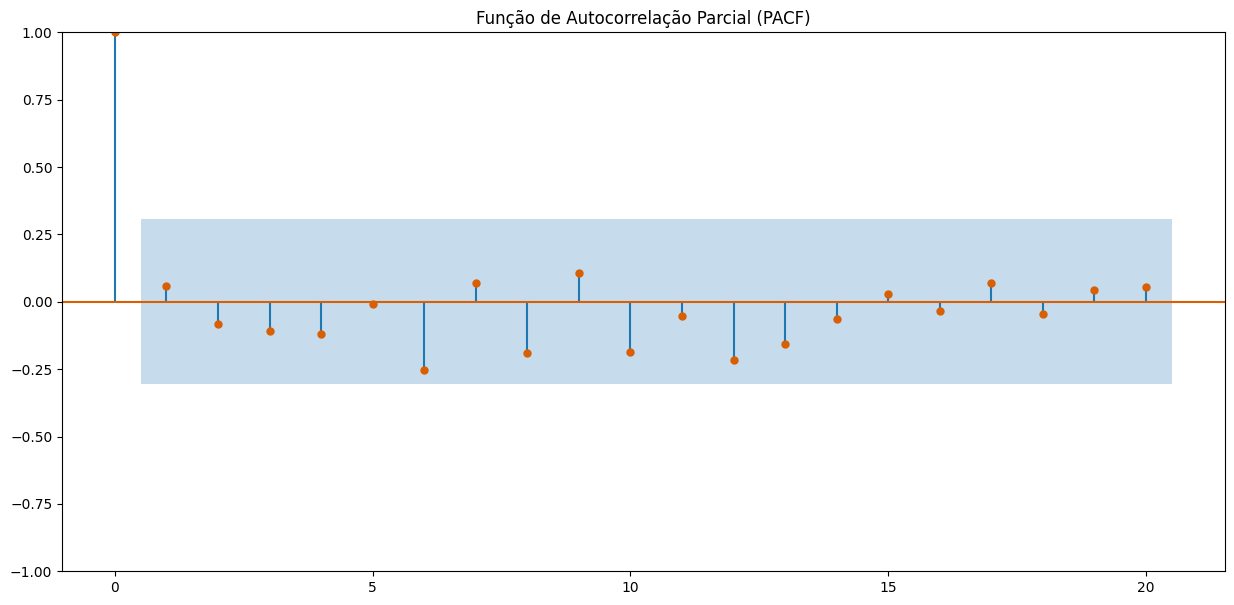

In [4]:
plot_pacf(serie_v1, lags=20, color='#d95f02', title='Função de Autocorrelação Parcial (PACF)')
plt.show()

# **Exemplo 2 - Série SEM Autocorrelação /Série COM Autocorrelação**

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1. Configuração de Reprodutibilidade
np.random.seed(42)
n = 300

# 2. Geração das Séries Temporais

# A. Série SEM Autocorrelação (Ruído Branco Gaussiano)
ruido_branco = np.random.normal(loc=0, scale=1.0, size=n)

# B. Série COM Autocorrelação (Processo AutoRegressivo AR(1) com phi = 0.8)
ar1 = np.zeros(n)
for t in range(1, n):
    ar1[t] = 0.8 * ar1[t-1] + np.random.normal(loc=0, scale=1.0)



## **Série SEM Autocorrelação (Ruído Branco)**

Text(0, 0.5, 'Valor')

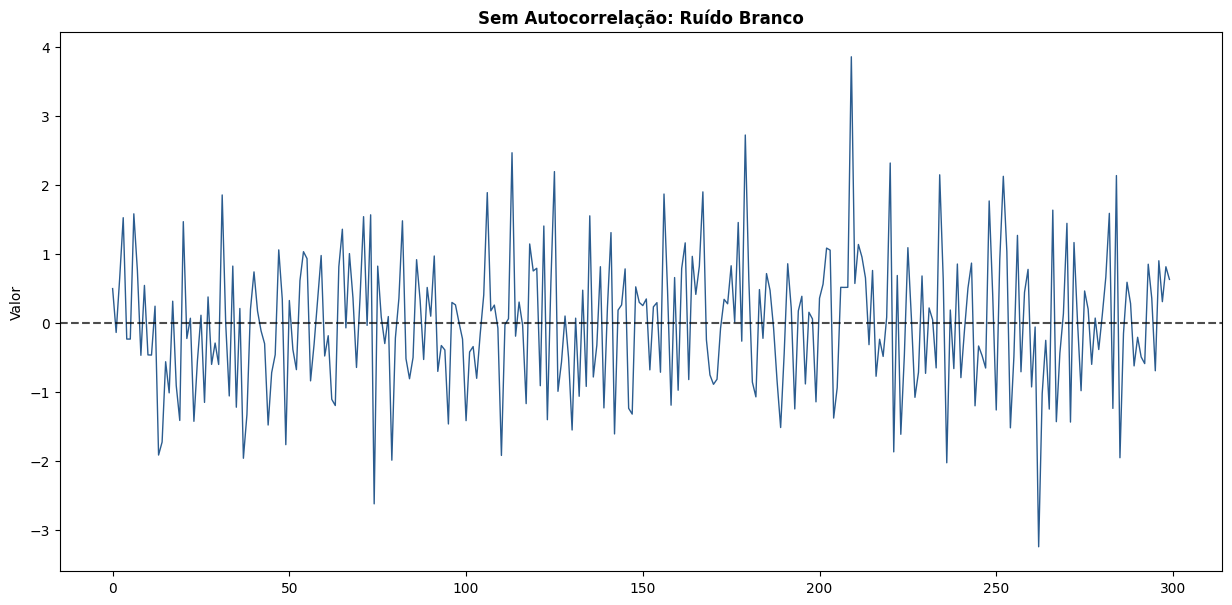

In [23]:
# ----------------------------------------------------
# Série SEM Autocorrelação (Ruído Branco)
# ----------------------------------------------------
plt.plot(ruido_branco, color='#2b5c8f', linewidth=1)
plt.axhline(0, color='black', linestyle='--', alpha=0.7)
plt.title('Sem Autocorrelação: Ruído Branco', fontweight='bold')
plt.ylabel('Valor')



(-0.4, 1.1)

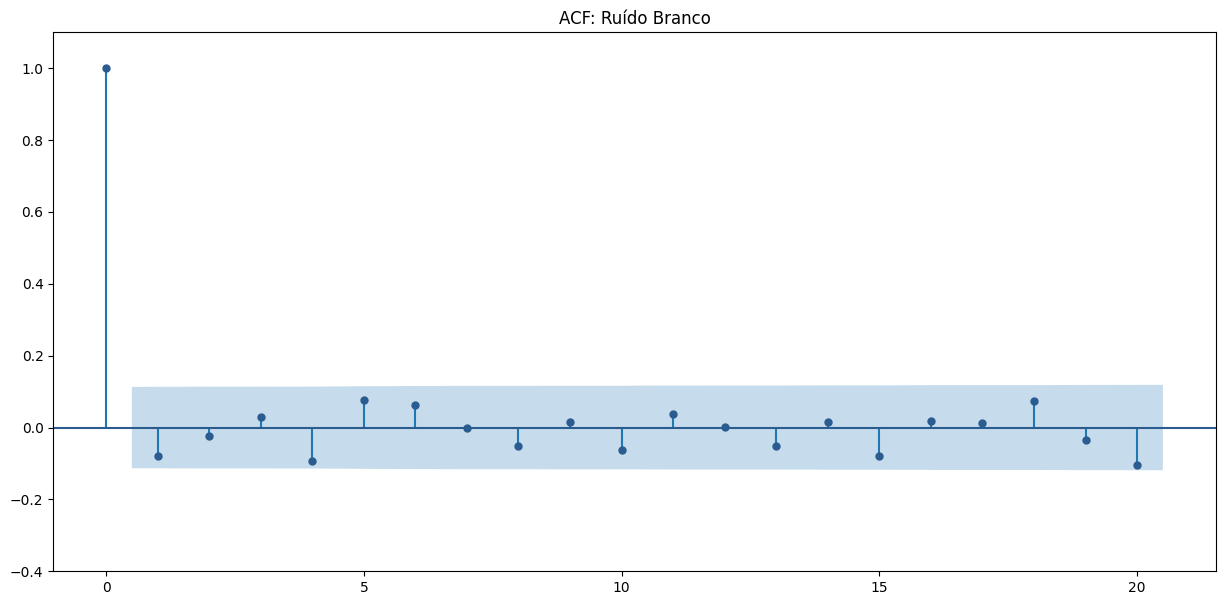

In [26]:
# ACF - Ruído Branco
plot_acf(ruido_branco, lags=20, color='#2b5c8f', title='ACF: Ruído Branco')
plt.ylim(-0.4, 1.1)


(-0.4, 1.1)

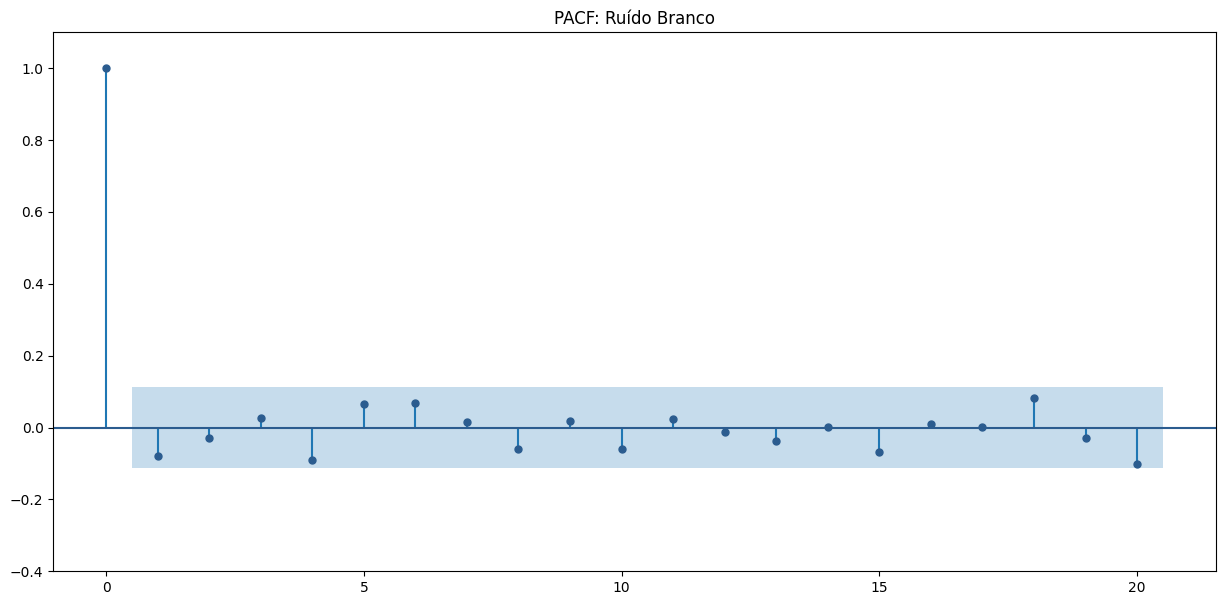

In [25]:
# PACF - Ruído Branco
plot_pacf(ruido_branco, lags=20,color='#2b5c8f', title='PACF: Ruído Branco', method='ywm')
plt.ylim(-0.4, 1.1)

## **Série COM Autocorrelação (Processo AR(1))**

<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_2206/2429016616.py:6: SyntaxWarning: invalid escape sequence '\p'
  plt.title('Com Autocorrelação: Processo AR(1) ($\phi=0.8$)', fontweight='bold')


Text(0, 0.5, 'Valor')

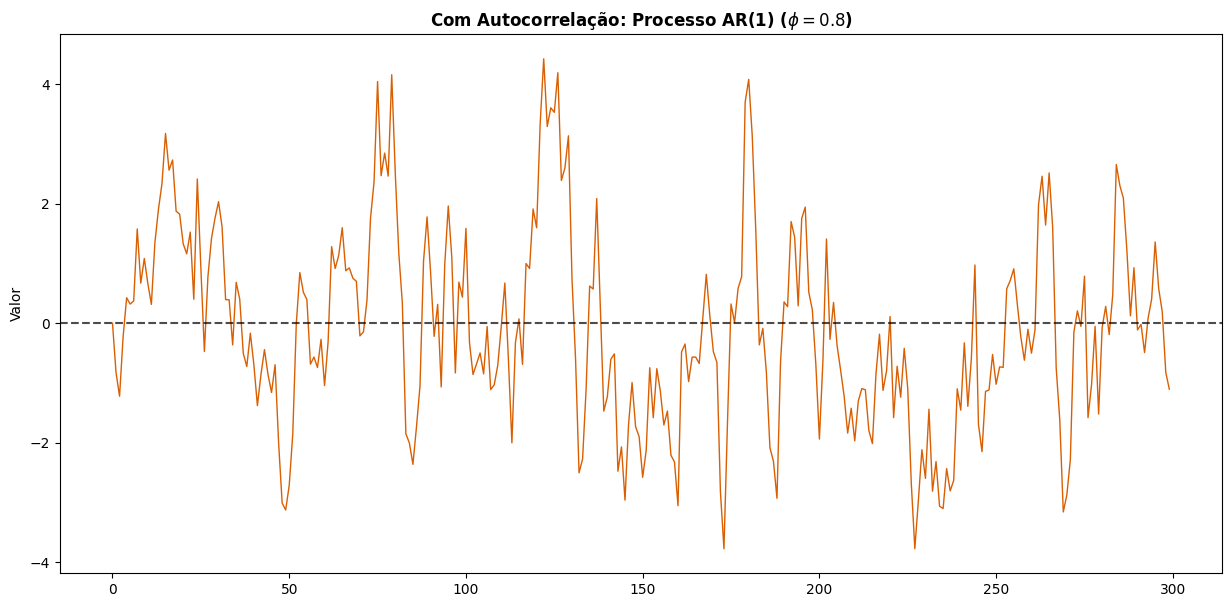

In [27]:
# ----------------------------------------------------
# Série COM Autocorrelação (Processo AR(1))
# ----------------------------------------------------
plt.plot(ar1, color='#d95f02', linewidth=1)
plt.axhline(0, color='black', linestyle='--', alpha=0.7)
plt.title('Com Autocorrelação: Processo AR(1) ($\phi=0.8$)', fontweight='bold')
plt.ylabel('Valor')

(-0.4, 1.1)

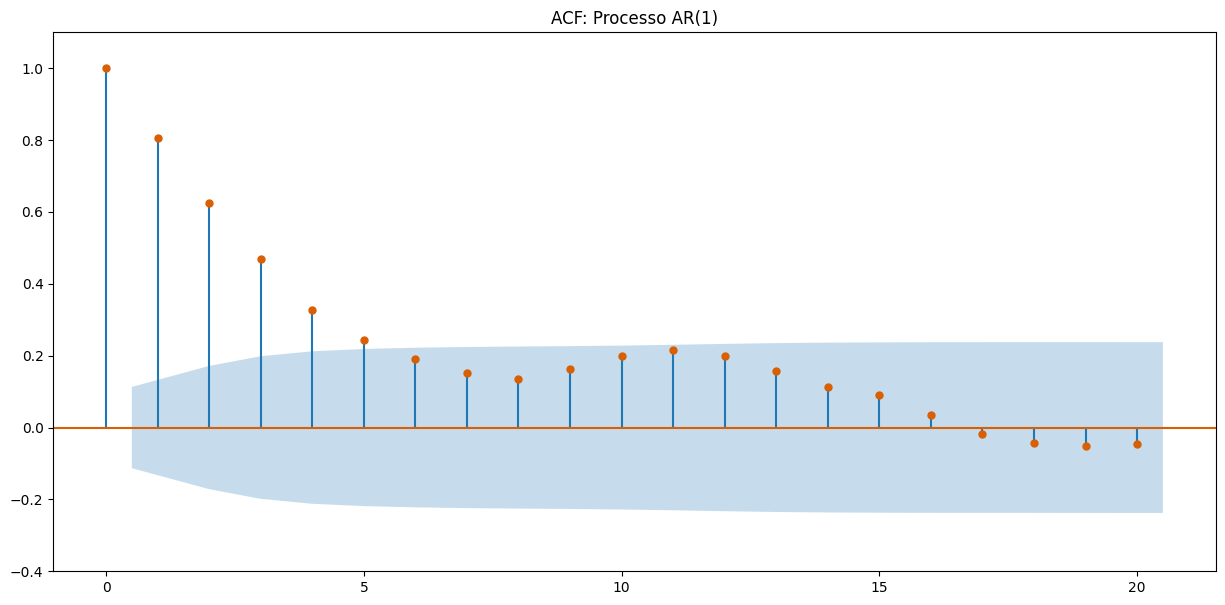

In [29]:
# ACF - AR(1)
plot_acf(ar1, lags=20,color='#d95f02', title='ACF: Processo AR(1)')
plt.ylim(-0.4, 1.1)


(-0.4, 1.1)

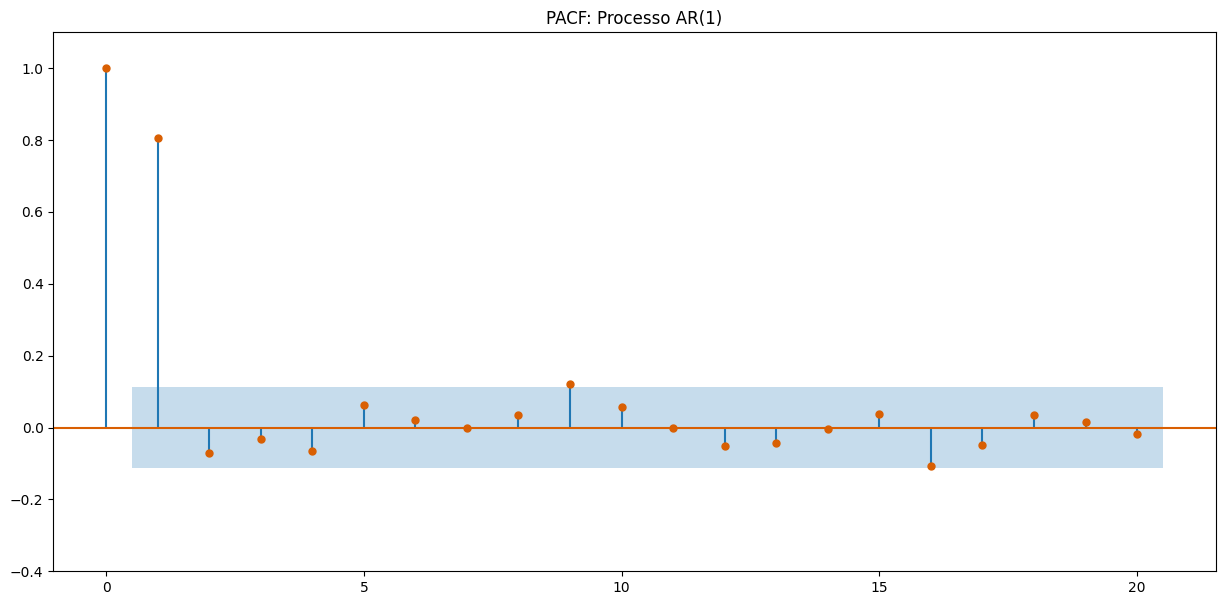

In [30]:

# PACF - AR(1)
plot_pacf(ar1, lags=20, color='#d95f02', title='PACF: Processo AR(1)', method='ywm')
plt.ylim(-0.4, 1.1)

# **Exemplo 3 - Air Passengers**

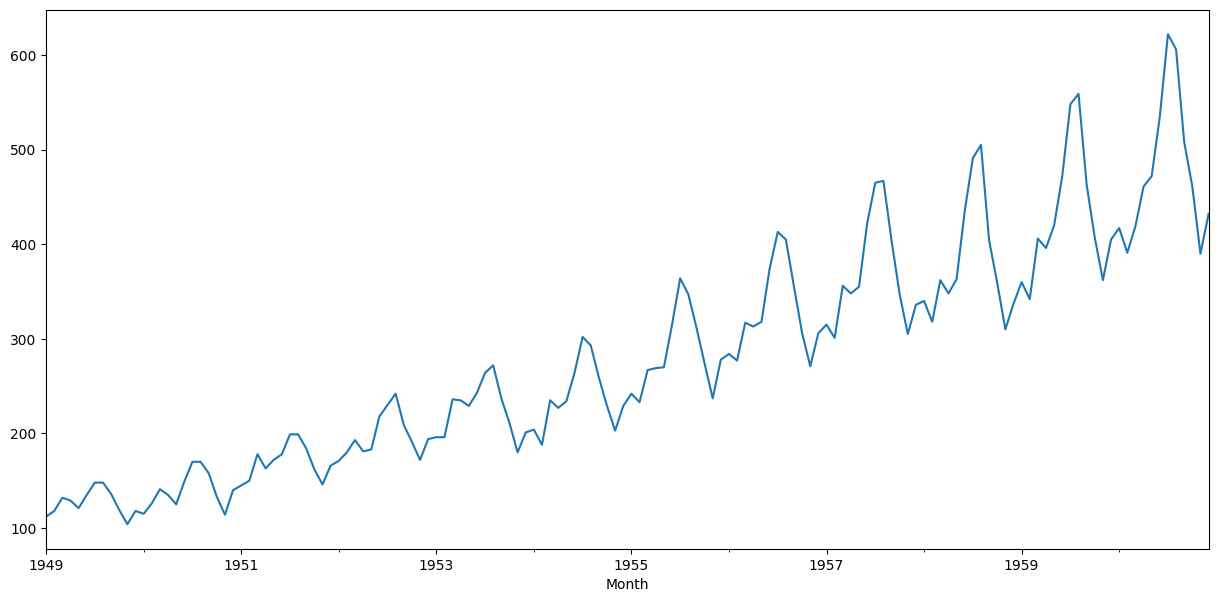

In [31]:
# 1. Carregamento do dataset clássico AirPassengers
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)

# Ajuste do índice temporal
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)
df.rename(columns={'Passengers': 'Passageiros'}, inplace=True)
serie_passageiros = pd.Series(df['Passageiros'].values, index=df.index)
serie_passageiros.plot()
plt.show()


In [32]:
# 2. Cálculo dos valores numéricos da Autocorrelação (Lags 1 a 12)
acf_valores = sm.tsa.stattools.acf(serie_passageiros, nlags=48)

#print("--- COEFICIENTES DE AUTOCORRELAÇÃO (ACF) ---")
#for lag, val in enumerate(acf_valores):
#    print(f"Lag {lag:2d}: {val:.4f}")

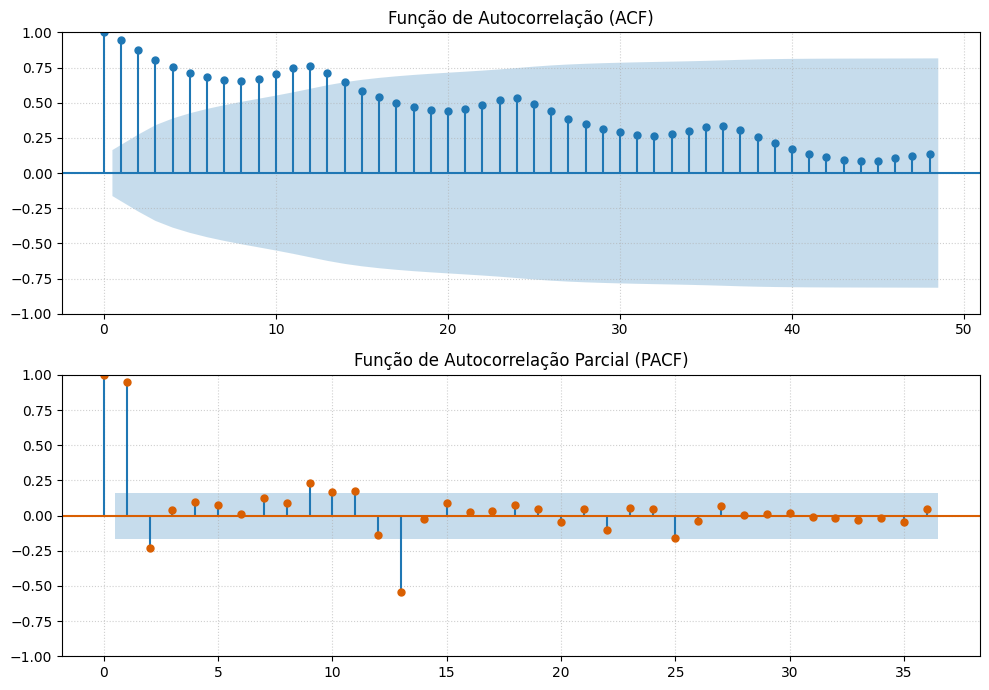

In [33]:
# 3. Construção dos Correlogramas (ACF e PACF)
fig, axes = plt.subplots(2, 1, figsize=(10, 7))

# Plot da Função de Autocorrelação (ACF)
plot_acf(serie_passageiros, lags=48, ax=axes[0], color='#1f77b4', title='Função de Autocorrelação (ACF)')
axes[0].grid(True, linestyle=':', alpha=0.6)

# Plot da Função de Autocorrelação Parcial (PACF)
plot_pacf(serie_passageiros, lags=36, ax=axes[1], color='#d95f02', title='Função de Autocorrelação Parcial (PACF)')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# **Exemplo 4- Sunspots (Manchas Solares)**

A série temporal Sunspot (manchas solares) regista a quantidade anual ou mensal de manchas visíveis na superfície do Sol. É uma das séries temporais históricas mais antigas e estudadas no mundo, com registos que remontam a 1700 (e medições diárias desde 1818.

In [34]:
import pandas as pd
from pandas.core.series import Series
import matplotlib.pyplot as plt

In [35]:
dataset = pd.read_csv('/content/drive/MyDrive/Série_temporais_A1/Bases_de_dados/Sunspots2.csv')
print(dataset.tail(10))

            Date  Monthly Mean Total Sunspot Number
3255  2020-04-30                                5.2
3256  2020-05-31                                0.2
3257  2020-06-30                                5.8
3258  2020-07-31                                6.1
3259  2020-08-31                                7.5
3260  2020-09-30                                0.6
3261  2020-10-31                               14.4
3262  2020-11-30                               34.0
3263  2020-12-31                               21.8
3264  2021-01-31                               10.4


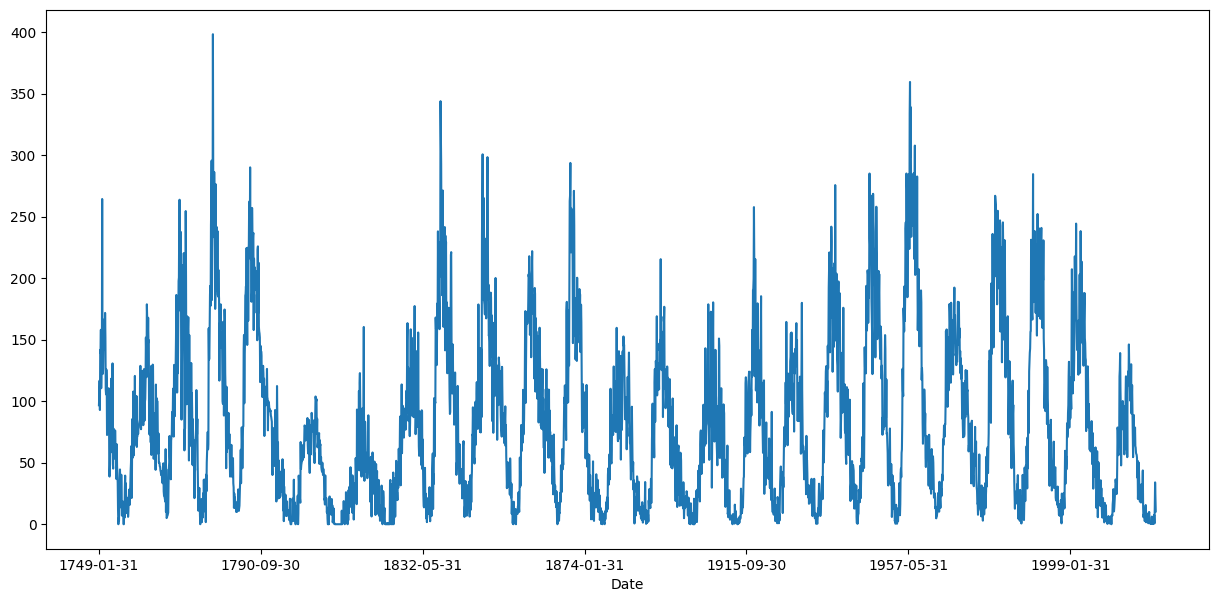

In [36]:

serie_sunspots =pd.Series(dataset['Monthly Mean Total Sunspot Number'].values, index=dataset['Date'])
serie_sunspots.plot()
plt.show()

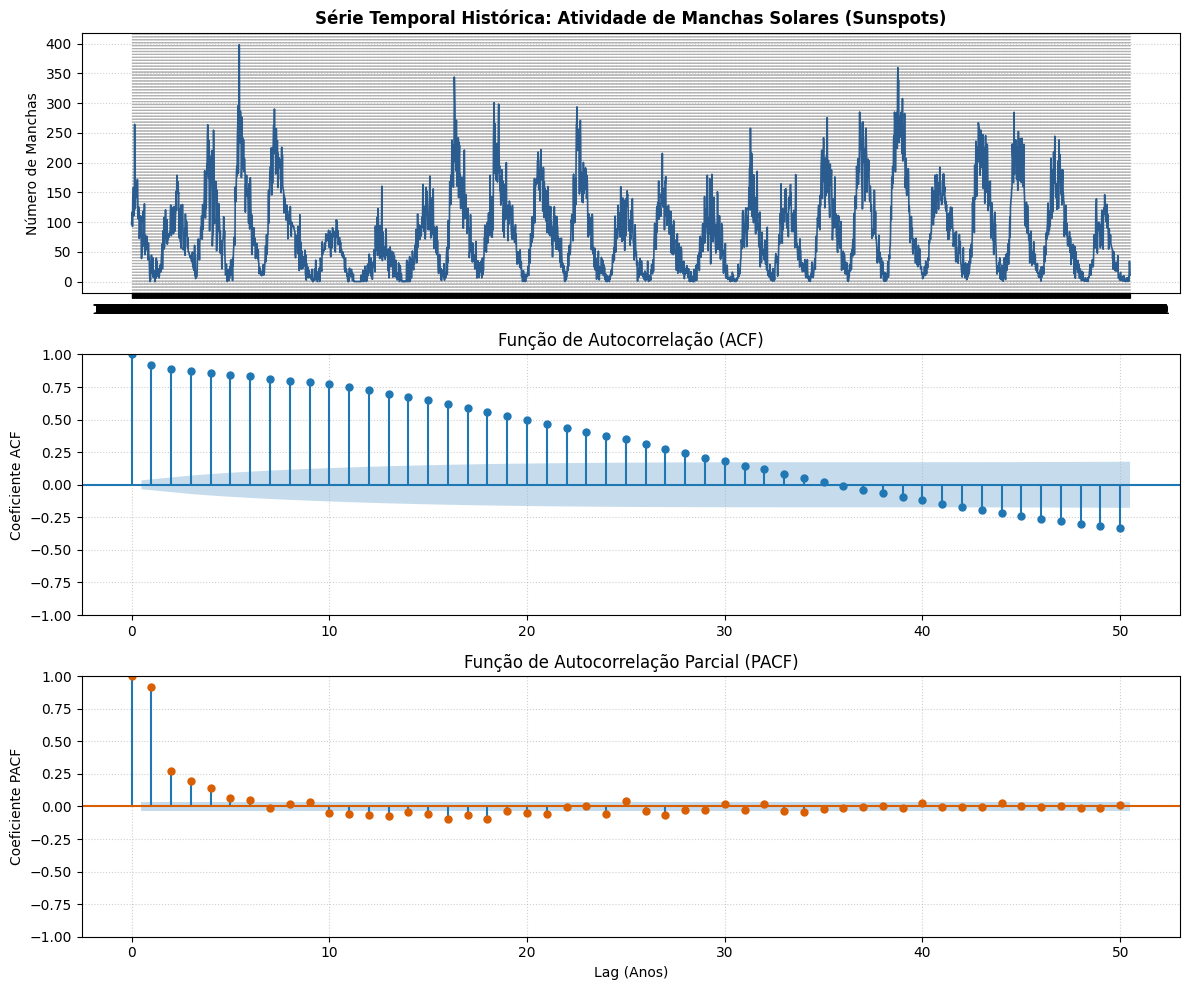

In [37]:

# 2. Configuração do Grid de Gráficos
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Plot 1: Série Temporal das Manchas Solares
axes[0].plot(serie_sunspots, color='#2b5c8f', linewidth=1.2)
axes[0].set_title('Série Temporal Histórica: Atividade de Manchas Solares (Sunspots)', fontweight='bold')
axes[0].set_ylabel('Número de Manchas')
axes[0].grid(True, linestyle=':', alpha=0.6)

# Plot 2: Função de Autocorrelação (ACF)
plot_acf(serie_sunspots, lags=50, ax=axes[1], color='#1f77b4', title='Função de Autocorrelação (ACF)')
axes[1].set_ylabel('Coeficiente ACF')
axes[1].grid(True, linestyle=':', alpha=0.6)

# Plot 3: Função de Autocorrelação Parcial (PACF)
plot_pacf(serie_sunspots, lags=50, ax=axes[2], color='#d95f02', title='Função de Autocorrelação Parcial (PACF)', method='ywm')
axes[2].set_xlabel('Lag (Anos)')
axes[2].set_ylabel('Coeficiente PACF')
axes[2].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# **Analise dos resultados**

Ao analisar os gráficos gerados pelo código, identificam-se três comportamentos estruturais:

**Padrão Ciclos Solares na ACF:** A Função de Autocorrelação exibe uma onda senoidal perfeita com decaimento lento. Observe os picos positivos ocorrendo aproximadamente a cada 10 a 11 lags (lags 11, 22, 33). Isso confirma matematicamente o ciclo de atividade magnética do Sol.

**Comportamento Autoregressivo na PACF:** A PACF apresenta picos altamente significativos nos lags 1 e 2, caindo de forma drástica logo em seguida